In [1]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import suncalc

import dask.dataframe as dd
from pathlib import Path
import glob
import re

import datetime as dt
import pytz

import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches

In [2]:
import sys

sys.path.append("../src")
sys.path.append("../src/bout")
sys.path.append("../src/tests")

In [3]:
import clustering as clstr
import bout.assembly as bt
import plot as bt_plt
import test_activity_metric_functions as test_actvt
import activity.subsampling as ss
import activity.activity_assembly as actvt
import pipeline
from core import SITE_NAMES, FREQUENCY_COLOR_MAPPINGS

from cli import get_file_paths
import pipeline

In [4]:
def plot_dets_over_audio_seg(audio_features, spec_features, plot_dets, data_params):
    """
    Function to plot the spectrogram of a provided audio segment with overlayed detections
    """

    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    file_dt = dt.datetime.strptime(audio_features['file_path'].name, '%Y%m%d_%H%M%S.WAV')

    UBNA_tz = pytz.timezone('US/Pacific')
    UTC_tz = pytz.timezone('UTC')

    file_dt_UTC = UTC_tz.localize(file_dt)
    file_dt_PST = file_dt_UTC.astimezone(UBNA_tz)
    file_title = f'{file_dt_PST.date()} {file_dt_PST.time()} PST'

    on = int(data_params['cur_dc_tag'].split('of')[0])
    total = int(data_params['cur_dc_tag'].split('of')[1])

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 24})
    # plt.title(f"Audiomoth file recorded at {file_title}", fontsize=22)
    plt.specgram(audio_seg, NFFT=spec_features['NFFT'], cmap=spec_features['cmap'], vmax=0, vmin=spec_features['vmin'])

    green_patch = patches.Patch(facecolor='lightgreen', edgecolor='k', label='Recording period')
    blue_patch = patches.Patch(facecolor='royalblue', edgecolor='k', label='Sleep period')
    yellow_patch = patches.Patch(facecolor='yellow', edgecolor='k', label='Detected calls')
    orange_patch = patches.Patch(facecolor='orange', edgecolor='k', label='High-frequency calls')
    cyan_patch = patches.Patch(facecolor='cyan', edgecolor='k', label='Low-frequency calls')

    legend_patches = [yellow_patch]
    ax = plt.gca()
    for i, row in plot_dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                        (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                        linewidth=1, edgecolor='yellow', facecolor='none', alpha=0.8)
        
        ax.add_patch(rect)


    windows_PST = pd.date_range(file_dt_PST+pd.Timedelta(seconds=start), file_dt_PST+pd.Timedelta(seconds=start)+pd.Timedelta(seconds=duration), freq=f'{duration/5}S', inclusive='both')

    plt.yticks(ticks=np.linspace(0, 1*(96/125), 6), labels=np.linspace(0, 192000/2000, 6).astype('int'))
    # plt.xticks(ticks=np.linspace(0, duration*(fs/2), len(windows_PST)), labels=windows_PST.strftime('%-M:%-S'), color='k')
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), len(windows_PST)), labels=np.linspace(0, duration, len(windows_PST)).round(2), color='k')
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (secs)")
    plt.ylim(0, 96/125)
    plt.legend(handles=legend_patches, fontsize=14, ncol=1, loc='upper right')

    plt.tight_layout()
    plt.show()

def plot_colored_dets_over_audio_seg(audio_features, spec_features, plot_dets, data_params):
    """
    Function to plot the spectrogram of a provided audio segment with overlayed detections
    """

    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    file_dt = dt.datetime.strptime(audio_features['file_path'].name, '%Y%m%d_%H%M%S.WAV')

    UBNA_tz = pytz.timezone('US/Pacific')
    UTC_tz = pytz.timezone('UTC')

    file_dt_UTC = UTC_tz.localize(file_dt)
    file_dt_PST = file_dt_UTC.astimezone(UBNA_tz)
    file_title = f'{file_dt_PST.date()} {file_dt_PST.time()} PST'

    on = int(data_params['cur_dc_tag'].split('of')[0])
    total = int(data_params['cur_dc_tag'].split('of')[1])

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 24})
    # plt.title(f"Audiomoth file recorded at {file_title}", fontsize=22)
    plt.specgram(audio_seg, NFFT=spec_features['NFFT'], cmap=spec_features['cmap'], vmax=0, vmin=spec_features['vmin'])

    green_patch = patches.Patch(facecolor='lightgreen', edgecolor='k', label='Recording period')
    blue_patch = patches.Patch(facecolor='royalblue', edgecolor='k', label='Sleep period')
    yellow_patch = patches.Patch(facecolor='yellow', edgecolor='k', label='Detected calls')
    orange_patch = patches.Patch(facecolor='orange', edgecolor='k', label='High-frequency calls')
    cyan_patch = patches.Patch(facecolor='cyan', edgecolor='k', label='Low-frequency calls')

    legend_patches = [yellow_patch]
    ax = plt.gca()
    for i, row in plot_dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                        (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                        linewidth=1, edgecolor=FREQUENCY_COLOR_MAPPINGS[row['freq_group']], facecolor='none', alpha=0.8)
        
        ax.add_patch(rect)


    windows_PST = pd.date_range(file_dt_PST+pd.Timedelta(seconds=start), file_dt_PST+pd.Timedelta(seconds=start)+pd.Timedelta(seconds=duration), freq=f'{duration/5}S', inclusive='both')

    plt.yticks(ticks=np.linspace(0, 1*(96/125), 6), labels=np.linspace(0, 192000/2000, 6).astype('int'))
    # plt.xticks(ticks=np.linspace(0, duration*(fs/2), len(windows_PST)), labels=windows_PST.strftime('%-M:%-S'), color='k')
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), len(windows_PST)), labels=np.linspace(0, duration, len(windows_PST)).round(2), color='k')
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (secs)")
    plt.ylim(0, 96/125)
    plt.legend(handles=legend_patches, fontsize=14, ncol=1, loc='upper right')

    plt.tight_layout()
    plt.show()

def plot_bouts_over_audio_seg(audio_features, spec_features, bout_params, data_params, plot_dets, plot_bouts):
    """
    Function to plot the spectrogram of a provided audio segment with overlayed bouts and bout duurations.
    """
    
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    file_dt = dt.datetime.strptime(audio_features['file_path'].name, '%Y%m%d_%H%M%S.WAV')

    UBNA_tz = pytz.timezone('US/Pacific')
    UTC_tz = pytz.timezone('UTC')

    file_dt_UTC = UTC_tz.localize(file_dt)
    file_dt_PST = file_dt_UTC.astimezone(UBNA_tz)
    file_title = f'{file_dt_PST.date()} {file_dt_PST.time()} PST'

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 24})
    # plt.title(f"BCI-derived bouts using BD2 detections on {audio_features['file_path'].name}", fontsize=22)
    plt.specgram(audio_seg, NFFT=spec_features['NFFT'], cmap=spec_features['cmap'], vmin=spec_features['vmin'])

    legend_patches = []
    for group in bout_params.keys():
        type_tag = group.split('_')[0]
        
        if group != 'site_key' and (type_tag in plot_bouts['freq_group'].values):
            group_tag = group.split('_')[0]
            group_patch = patches.Patch(facecolor=FREQUENCY_COLOR_MAPPINGS[group_tag], edgecolor='k', label=f'{type_tag.upper()[:2]} Bout')
            legend_patches += [group_patch]

    ax = plt.gca()
    plot_bout_info(ax, audio_features, plot_bouts)
    if len(plot_dets)>0:
        for i, row in plot_dets.iterrows():
            rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                            (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                            linewidth=1, edgecolor='yellow', facecolor='none', alpha=0.8)
            
            ax.add_patch(rect)
    
    windows_PST = pd.date_range(file_dt_PST+pd.Timedelta(seconds=start), file_dt_PST+pd.Timedelta(seconds=start)+pd.Timedelta(seconds=duration), freq=f'{duration/5}S', inclusive='both')

    plt.yticks(ticks=np.linspace(0, 1*(96/125), 6), labels=np.linspace(0, 192000/2000, 6).astype('int'))
    # plt.xticks(ticks=np.linspace(0, duration*(fs/2), len(windows_PST)), labels=windows_PST.strftime('%-M:%-S'), color='k')
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), len(windows_PST)), labels=np.linspace(0, duration, len(windows_PST)).round(2), color='k')
    plt.ylabel("Frequency (kHz)")
    # plt.xlabel("Time (MM:SS)")
    plt.xlabel("Time (secs)")
    plt.ylim(0, 96/125)
    # plt.gcf().autofmt_xdate()
    plt.legend(handles=legend_patches, fontsize=14, ncol=int(len(legend_patches)), loc='upper right')

    plt.tight_layout()
    plt.show()


def plot_bout_info(ax, audio_features, plot_bouts):
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    for i, row in plot_bouts.iterrows():
        # if duration < 600:
            # plt.text(x=(row['start_time'] - start + (row['bout_duration_in_secs']/5))*(fs/2), y=min((row['high_freq']+2000)/(fs/2), 9/10), 
            #                     s=f"{round(row['bout_duration_in_secs'], 2)}s", color='pink', weight='bold', fontsize=9)
            # plt.text(x=(row['start_time'] - start + (row['bout_duration_in_secs']/5))*(fs/2), y=min((row['high_freq']+12000)/(fs/2), 9/10), 
            #                     s=f"{round(row['number_of_dets'], 2)} dets", color='pink', weight='bold', fontsize=9)
        rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                        (row['bout_duration_in_secs'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                        linewidth=2, edgecolor=FREQUENCY_COLOR_MAPPINGS[row['freq_group']], facecolor='none', alpha=0.8)
        ax.add_patch(rect)

In [5]:
site_key = 'Carp'
freq_key = ''

data_params = dict()
data_params['site_tag'] = site_key
data_params['type_tag'] = freq_key
data_params['detector_tag'] = 'bd2'
data_params['assembly_type'] = 'kmeans'
data_params['recording_start'] = '00:00'
data_params['recording_end'] = '16:00'
file_paths = get_file_paths(data_params)

location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', index_col=0)
bout_params = bt.get_bout_params_from_location(location_df, data_params)

In [6]:
bout_params

{'site_key': 'Carp', 'LF_bci': 4957.053823613828, 'HF_bci': 4336.239816109756}

In [7]:
files_from_loc = sorted(list(Path(f'../data/audiomoth_recordings/').glob(pattern=f'*/{site_key}/*.WAV')))
files_from_loc

[PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220727_080000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_030000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_033000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_040000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_043000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_050000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_053000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_060000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_063000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_070000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_073000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220

In [8]:
file = files_from_loc[11]
file

PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_080000.WAV')

In [9]:
file_path = Path(file)
filename = file_path.name
audio_file = sf.SoundFile(file_path)
fs = audio_file.samplerate
start = 76+19
duration = 4
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))
vmax = 0 # hide anything below -rm_dB dB
vmin = -40 # hide anything below -rm_dB dB
data_params['cur_dc_tag'] = '30of30'
data_params['cycle_length'] = int(data_params['cur_dc_tag'].split('of')[-1])
data_params['time_on'] = int(data_params['cur_dc_tag'].split('of')[0])
data_params['time_on_in_secs'] = 60*data_params['time_on']
data_params['recording_alpha'] = 0.0

file_dt_start = dt.datetime.strptime(filename, '%Y%m%d_%H%M%S.WAV')
file_dt_end = file_dt_start + pd.Timedelta(minutes=30)

In [10]:
dc_applied_df = ss.simulate_dutycycle_on_detections(location_df.copy(), data_params)
bout_metrics = bt.generate_bout_metrics_for_location_and_freq(dc_applied_df, data_params, bout_params)

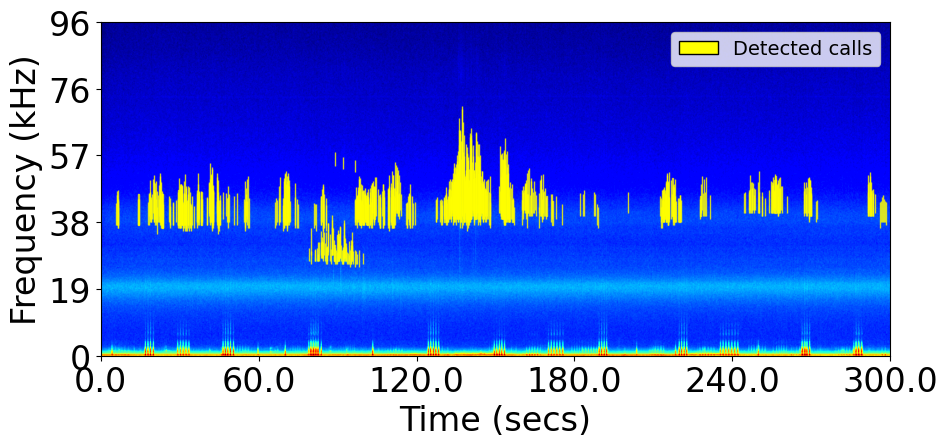

In [13]:
start = 0
duration = 300
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))
vmax = 0 # hide anything below -rm_dB dB
vmin = -60 # hide anything below -rm_dB dB

plot_dets = dc_applied_df.loc[(dc_applied_df['call_start_time']>=file_dt_start)&(dc_applied_df['call_end_time']<=file_dt_end)]
plot_dets = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start, plot_dets['end_time'] <= (start+duration))]

plot_bouts = bout_metrics.loc[(bout_metrics['start_time_of_bout']>=file_dt_start)&(bout_metrics['end_time_of_bout']<=file_dt_end)]
plot_bouts = plot_bouts.loc[np.logical_and(plot_bouts['start_time'] >= start, plot_bouts['end_time'] <= (start+duration))]

audio_features = dict()
audio_features['file_path'] = file_path
audio_features['audio_seg'] = audio_seg
audio_features['sample_rate'] = fs
audio_features['start'] = start
audio_features['duration'] = duration
audio_features['figsize'] = (10, 5)

spec_features = dict()
spec_features['vmax'] = vmax
spec_features['vmin'] = vmin
spec_features['NFFT'] = 1024
spec_features['cmap'] = 'jet'

plot_dets_over_audio_seg(audio_features, spec_features, plot_dets, data_params)

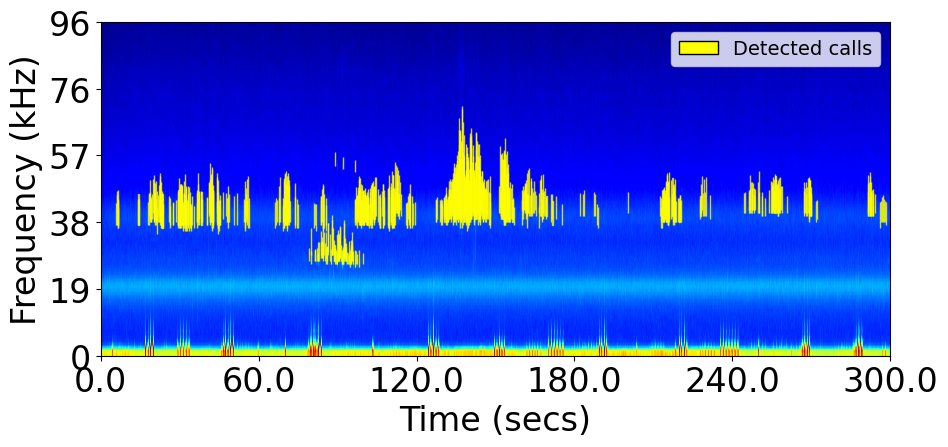

In [43]:
start = 0
duration = 300
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))
vmax = 0 # hide anything below -rm_dB dB
vmin = -60 # hide anything below -rm_dB dB

plot_dets = dc_applied_df.loc[(dc_applied_df['call_start_time']>=file_dt_start)&(dc_applied_df['call_end_time']<=file_dt_end)]
plot_dets = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start, plot_dets['end_time'] <= (start+duration))]

plot_bouts = bout_metrics.loc[(bout_metrics['start_time_of_bout']>=file_dt_start)&(bout_metrics['end_time_of_bout']<=file_dt_end)]
plot_bouts = plot_bouts.loc[np.logical_and(plot_bouts['start_time'] >= start, plot_bouts['end_time'] <= (start+duration))]

audio_features = dict()
audio_features['file_path'] = file_path
audio_features['audio_seg'] = audio_seg
audio_features['sample_rate'] = fs
audio_features['start'] = start
audio_features['duration'] = duration
audio_features['figsize'] = (10, 5)

spec_features = dict()
spec_features['vmax'] = vmax
spec_features['vmin'] = vmin
spec_features['NFFT'] = 256
spec_features['cmap'] = 'jet'

plot_dets_over_audio_seg(audio_features, spec_features, plot_dets, data_params)

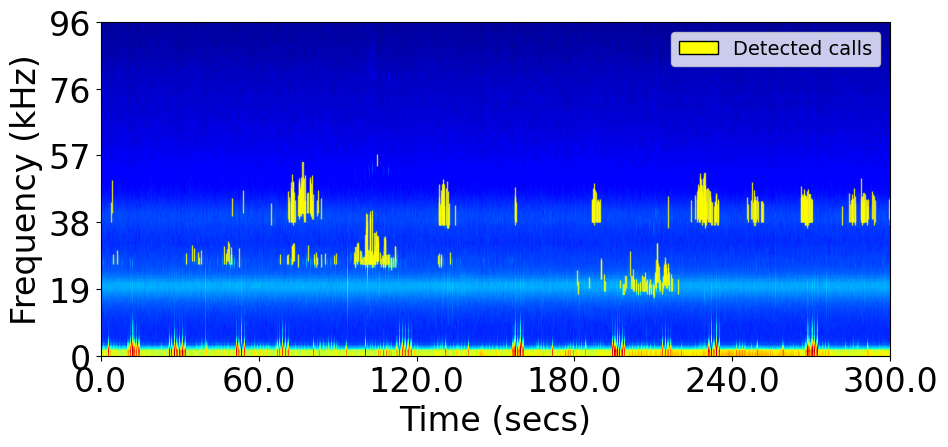

In [44]:
start = 300
duration = 300
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))
vmax = 0 # hide anything below -rm_dB dB
vmin = -60 # hide anything below -rm_dB dB

plot_dets = dc_applied_df.loc[(dc_applied_df['call_start_time']>=file_dt_start)&(dc_applied_df['call_end_time']<=file_dt_end)]
plot_dets = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start, plot_dets['end_time'] <= (start+duration))]

plot_bouts = bout_metrics.loc[(bout_metrics['start_time_of_bout']>=file_dt_start)&(bout_metrics['end_time_of_bout']<=file_dt_end)]
plot_bouts = plot_bouts.loc[np.logical_and(plot_bouts['start_time'] >= start, plot_bouts['end_time'] <= (start+duration))]

audio_features = dict()
audio_features['file_path'] = file_path
audio_features['audio_seg'] = audio_seg
audio_features['sample_rate'] = fs
audio_features['start'] = start
audio_features['duration'] = duration
audio_features['figsize'] = (10, 5)

spec_features = dict()
spec_features['vmax'] = vmax
spec_features['vmin'] = vmin
spec_features['NFFT'] = 256
spec_features['cmap'] = 'jet'

plot_dets_over_audio_seg(audio_features, spec_features, plot_dets, data_params)

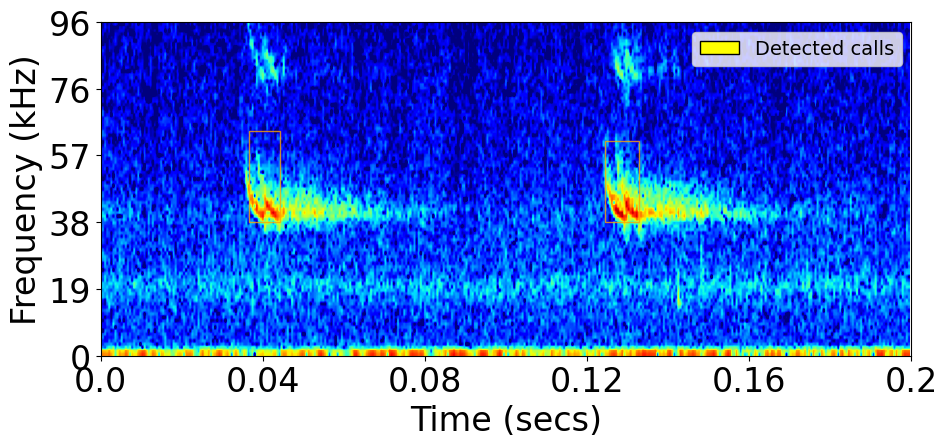

In [13]:
start = 136.61
duration = 0.2
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))
vmax = 0 # hide anything below -rm_dB dB
vmin = -60 # hide anything below -rm_dB dB

plot_dets = dc_applied_df.loc[(dc_applied_df['call_start_time']>=file_dt_start)&(dc_applied_df['call_end_time']<=file_dt_end)]
plot_dets = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start, plot_dets['end_time'] <= (start+duration))]

plot_bouts = bout_metrics.loc[(bout_metrics['start_time_of_bout']>=file_dt_start)&(bout_metrics['end_time_of_bout']<=file_dt_end)]
plot_bouts = plot_bouts.loc[np.logical_and(plot_bouts['start_time'] >= start, plot_bouts['end_time'] <= (start+duration))]

audio_features = dict()
audio_features['file_path'] = file_path
audio_features['audio_seg'] = audio_seg
audio_features['sample_rate'] = fs
audio_features['start'] = start
audio_features['duration'] = duration
audio_features['figsize'] = (10, 5)

spec_features = dict()
spec_features['vmax'] = vmax
spec_features['vmin'] = vmin
spec_features['NFFT'] = 256
spec_features['cmap'] = 'jet'

plot_colored_dets_over_audio_seg(audio_features, spec_features, plot_dets, data_params)

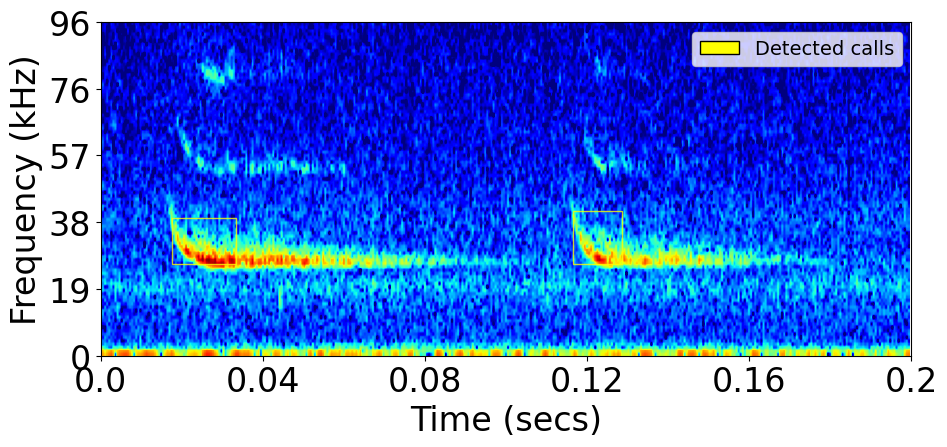

In [14]:
start = 402.15
duration = 0.2
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))
vmax = 0 # hide anything below -rm_dB dB
vmin = -60 # hide anything below -rm_dB dB

plot_dets = dc_applied_df.loc[(dc_applied_df['call_start_time']>=file_dt_start)&(dc_applied_df['call_end_time']<=file_dt_end)]
plot_dets = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start, plot_dets['end_time'] <= (start+duration))]

plot_bouts = bout_metrics.loc[(bout_metrics['start_time_of_bout']>=file_dt_start)&(bout_metrics['end_time_of_bout']<=file_dt_end)]
plot_bouts = plot_bouts.loc[np.logical_and(plot_bouts['start_time'] >= start, plot_bouts['end_time'] <= (start+duration))]

audio_features = dict()
audio_features['file_path'] = file_path
audio_features['audio_seg'] = audio_seg
audio_features['sample_rate'] = fs
audio_features['start'] = start
audio_features['duration'] = duration
audio_features['figsize'] = (10, 5)

spec_features = dict()
spec_features['vmax'] = vmax
spec_features['vmin'] = vmin
spec_features['NFFT'] = 256
spec_features['cmap'] = 'jet'

plot_dets_over_audio_seg(audio_features, spec_features, plot_dets, data_params)

In [15]:
bouts_in_file = plot_bouts.loc[(plot_bouts['bout_duration_in_secs']>10)&(plot_bouts['freq_group']=='LF1')].sort_values(by='start_time')

In [16]:
selected_bout = bouts_in_file.iloc[1:2]
selected_bout

,start_time_of_bout,end_time_of_bout,start_time_wrt_ref,end_time_wrt_ref,start_time,end_time,low_freq,high_freq,freq_group,cycle_ref_time_start,cycle_ref_time_end,number_of_dets,bout_duration,bout_duration_in_secs


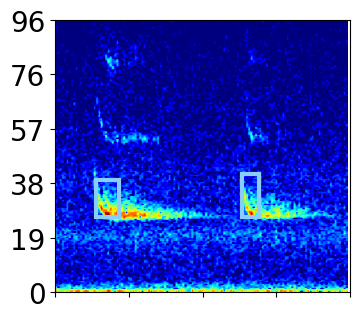

In [11]:
start = 402.14
duration = 0.2

plot_dets = dc_applied_df.loc[(dc_applied_df['call_start_time']>=file_dt_start)&(dc_applied_df['call_end_time']<=file_dt_end)]
plot_dets = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start, plot_dets['end_time'] <= (start+duration))]

plot_bouts = bout_metrics.loc[(bout_metrics['start_time_of_bout']>=file_dt_start)&(bout_metrics['end_time_of_bout']<=file_dt_end)]
plot_bouts = plot_bouts.loc[np.logical_and(plot_bouts['start_time'] >= start, plot_bouts['end_time'] <= (start+duration))]
audio_file.seek(int(fs*start))
audio_bout = audio_file.read(int(fs*duration))

vmax = 20*np.log10(np.max(audio_bout)) # hide anything below -rm_dB dB
vmin = 20*np.log10(np.max(audio_bout)) - 40 # hide anything below -rm_dB dB

audio_features = dict()
audio_features['file_path'] = file_path
audio_features['audio_seg'] = audio_bout
audio_features['sample_rate'] = fs
audio_features['start'] = start
audio_features['duration'] = duration
audio_features['figsize'] = (4, 3.6)

spec_features = dict()
spec_features['vmax'] = vmax
spec_features['vmin'] = vmin
spec_features['NFFT'] = 512
spec_features['cmap'] = 'jet'
audio_seg = audio_features['audio_seg']
fs = audio_features['sample_rate']
start = audio_features['start']
duration = audio_features['duration']

file_dt = dt.datetime.strptime(audio_features['file_path'].name, '%Y%m%d_%H%M%S.WAV')
UBNA_tz = pytz.timezone('US/Pacific')
UTC_tz = pytz.timezone('UTC')

file_dt_UTC = UTC_tz.localize(file_dt)
file_dt_PST = file_dt_UTC.astimezone(UBNA_tz)
file_title = f'{file_dt_PST.date()} {file_dt_PST.time()} PST'

plt.figure(figsize=audio_features['figsize'])
plt.rcParams.update({'font.size': 20})
plt.specgram(audio_seg, NFFT=spec_features['NFFT'], cmap=spec_features['cmap'], vmin=spec_features['vmin'])


ax = plt.gca()
for i, row in plot_dets.iterrows():
    # if row['freq_group'] == selected_bout.iloc[0]['freq_group']:
    rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                    (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                    linewidth=3, edgecolor=FREQUENCY_COLOR_MAPPINGS[row['freq_group']], facecolor='none', alpha=1)

    ax.add_patch(rect)

windows_PST = pd.date_range(file_dt_PST+pd.Timedelta(seconds=start), file_dt_PST+pd.Timedelta(seconds=start)+pd.Timedelta(seconds=duration), freq=f'{duration/4}S', inclusive='both')

plt.yticks(ticks=np.linspace(0, 1*(96/125), 6), labels=np.linspace(0, 192000/2000, 6).astype('int'))
# plt.yticks(ticks=np.linspace(0, 1*(96/125), 6), labels=['']*6)
plt.xticks(ticks=np.linspace(0, duration*(fs/2), len(windows_PST)), labels=['']*len(windows_PST), color='k')
plt.ylabel("")
plt.xlabel("")
plt.ylim(0, 96/125)

plt.tight_layout()
plt.show()

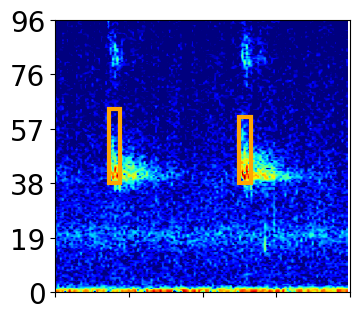

In [12]:
start = 136.61
duration = 0.2

plot_dets = dc_applied_df.loc[(dc_applied_df['call_start_time']>=file_dt_start)&(dc_applied_df['call_end_time']<=file_dt_end)]
plot_dets = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start, plot_dets['end_time'] <= (start+duration))]

plot_bouts = bout_metrics.loc[(bout_metrics['start_time_of_bout']>=file_dt_start)&(bout_metrics['end_time_of_bout']<=file_dt_end)]
plot_bouts = plot_bouts.loc[np.logical_and(plot_bouts['start_time'] >= start, plot_bouts['end_time'] <= (start+duration))]
audio_file.seek(int(fs*start))
audio_bout = audio_file.read(int(fs*duration))

vmax = 20*np.log10(np.max(audio_bout)) # hide anything below -rm_dB dB
vmin = 20*np.log10(np.max(audio_bout)) - 40 # hide anything below -rm_dB dB

audio_features = dict()
audio_features['file_path'] = file_path
audio_features['audio_seg'] = audio_bout
audio_features['sample_rate'] = fs
audio_features['start'] = start
audio_features['duration'] = duration
audio_features['figsize'] = (4, 3.6)

spec_features = dict()
spec_features['vmax'] = vmax
spec_features['vmin'] = vmin
spec_features['NFFT'] = 512
spec_features['cmap'] = 'jet'
audio_seg = audio_features['audio_seg']
fs = audio_features['sample_rate']
start = audio_features['start']
duration = audio_features['duration']

file_dt = dt.datetime.strptime(audio_features['file_path'].name, '%Y%m%d_%H%M%S.WAV')
UBNA_tz = pytz.timezone('US/Pacific')
UTC_tz = pytz.timezone('UTC')

file_dt_UTC = UTC_tz.localize(file_dt)
file_dt_PST = file_dt_UTC.astimezone(UBNA_tz)
file_title = f'{file_dt_PST.date()} {file_dt_PST.time()} PST'

plt.figure(figsize=audio_features['figsize'])
plt.rcParams.update({'font.size': 20})
plt.specgram(audio_seg, NFFT=spec_features['NFFT'], cmap=spec_features['cmap'], vmin=spec_features['vmin'])


ax = plt.gca()
for i, row in plot_dets.iterrows():
    # if row['freq_group'] == selected_bout.iloc[0]['freq_group']:
    rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                    (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                    linewidth=3, edgecolor=FREQUENCY_COLOR_MAPPINGS[row['freq_group']], facecolor='none', alpha=1)

    ax.add_patch(rect)

windows_PST = pd.date_range(file_dt_PST+pd.Timedelta(seconds=start), file_dt_PST+pd.Timedelta(seconds=start)+pd.Timedelta(seconds=duration), freq=f'{duration/4}S', inclusive='both')

plt.yticks(ticks=np.linspace(0, 1*(96/125), 6), labels=np.linspace(0, 192000/2000, 6).astype('int'))
# plt.yticks(ticks=np.linspace(0, 1*(96/125), 6), labels=['']*6)
plt.xticks(ticks=np.linspace(0, duration*(fs/2), len(windows_PST)), labels=['']*len(windows_PST), color='k')
plt.ylabel("")
plt.xlabel("")
plt.ylim(0, 96/125)

plt.tight_layout()
plt.show()

In [73]:
plot_dets

,start_time_wrt_ref,end_time_wrt_ref,index_in_file,peak_frequency,index_in_summary,input_file_dt,freq_group,ref_time,call_start_time,call_end_time,...,class,class_prob,det_prob,individual,input_file,Site name,Recover Folder,SD Card,File Duration,cycle_ref_time
241113,135.8335,135.8427,439,41280.0,243200,2022-07-28 08:00:00,HF,2022-07-28 08:02:15.833500,2022-07-28 08:02:15.833500,2022-07-28 08:02:15.842700,...,Pipistrellus nathusii,0.691,0.703,-1,/mnt/ubna_data_01_mir/recover-20220728/UBNA_00...,Carp Pond,recover-20220728,7,1795.0,2022-07-28 08:00:00
241114,135.9335,135.9422,440,41280.0,243201,2022-07-28 08:00:00,HF,2022-07-28 08:02:15.933500,2022-07-28 08:02:15.933500,2022-07-28 08:02:15.942200,...,Pipistrellus nathusii,0.615,0.650,-1,/mnt/ubna_data_01_mir/recover-20220728/UBNA_00...,Carp Pond,recover-20220728,7,1795.0,2022-07-28 08:00:00


In [123]:
# start = 402.15
# duration = 0.35
start = 390
duration = 30
audio_file.seek(int(fs*start))
audio_bout = audio_file.read(int(fs*duration))

vmax = 20*np.log10(np.max(audio_bout)) # hide anything below -rm_dB dB
vmin = 20*np.log10(np.max(audio_bout)) - 60 # hide anything below -rm_dB dB

audio_features = dict()
audio_features['file_path'] = file_path
audio_features['audio_seg'] = audio_bout
audio_features['sample_rate'] = fs
audio_features['start'] = start
audio_features['duration'] = duration
audio_features['figsize'] = (6, 5)

spec_features = dict()
spec_features['vmax'] = vmax
spec_features['vmin'] = vmin
spec_features['NFFT'] = 512
spec_features['cmap'] = 'jet'

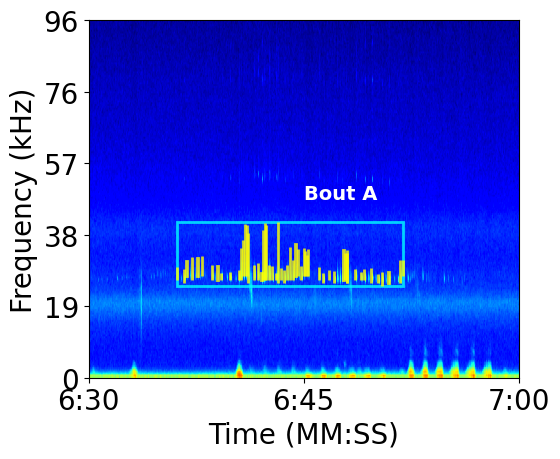

In [135]:
audio_seg = audio_features['audio_seg']
fs = audio_features['sample_rate']
start = audio_features['start']
duration = audio_features['duration']

file_dt = dt.datetime.strptime(audio_features['file_path'].name, '%Y%m%d_%H%M%S.WAV')
UBNA_tz = pytz.timezone('US/Pacific')
UTC_tz = pytz.timezone('UTC')

file_dt_UTC = UTC_tz.localize(file_dt)
file_dt_PST = file_dt_UTC.astimezone(UBNA_tz)
file_title = f'{file_dt_PST.date()} {file_dt_PST.time()} PST'

plt.figure(figsize=audio_features['figsize'])
plt.rcParams.update({'font.size': 20})
# plt.title(f"BCI-derived bouts using BD2 detections on {audio_features['file_path'].name}", fontsize=22)
plt.specgram(audio_seg, NFFT=spec_features['NFFT'], cmap=spec_features['cmap'], vmin=spec_features['vmin'])

legend_patches = []
for group in bout_params.keys():
    type_tag = group.split('_')[0]
    
    if group != 'site_key' and (type_tag in selected_bout['freq_group'].values):
        group_tag = group.split('_')[0]
        group_patch = patches.Patch(facecolor=FREQUENCY_COLOR_MAPPINGS[group_tag], edgecolor='k', label=f'{type_tag.upper()} Bout')
        legend_patches += [group_patch]

ax = plt.gca()
plot_bout_info(ax, audio_features, selected_bout)
plt.text(x=0.5, y=0.5, s='Bout A', color='w', fontsize=14, fontweight='bold', transform=ax.transAxes)
    
if len(plot_dets)>0:
    for i, row in plot_dets.iterrows():
        if row['freq_group'] == selected_bout.iloc[0]['freq_group']:
            rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                            (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                            linewidth=2, edgecolor='yellow', facecolor='none', alpha=0.8)
        
            ax.add_patch(rect)

windows_PST = pd.date_range(file_dt_PST+pd.Timedelta(seconds=start), file_dt_PST+pd.Timedelta(seconds=start)+pd.Timedelta(seconds=duration), freq=f'{duration/2}S', inclusive='both')

plt.yticks(ticks=np.linspace(0, 1*(96/125), 6), labels=np.linspace(0, 192000/2000, 6).astype('int'))
plt.xticks(ticks=np.linspace(0, duration*(fs/2), len(windows_PST)), labels=windows_PST.strftime('%-M:%S'), color='k')
plt.ylabel("Frequency (kHz)")
plt.xlabel("Time (MM:SS)")
plt.ylim(0, 96/125)
# plt.legend(handles=legend_patches, fontsize=14, ncol=int(len(legend_patches)), loc='upper right')

plt.tight_layout()
plt.show()

In [22]:
site_key = 'Carp'
input_dir = Path(f'../data/detected_calls/{site_key}')
choice_type = 'top1_inbouts'
filter_settings = '6ms_nobandpass'
signals = 'call_signals'
filepath = input_dir / f'2022_bd2{site_key}_{choice_type}_{filter_settings}_{signals}.npy'
if (filepath).exists():
    print(site_key)
    location_call_signals = np.load(filepath, allow_pickle=True)
    print(location_call_signals.shape)
    call_info = pd.read_csv(input_dir / f'2022_bd2{site_key}_{choice_type}.csv', index_col=0, low_memory=False)
    call_info['index'] = call_info.index

Carp
(38693,)


In [79]:
file_calls = call_info.loc[(call_info['file_name']==audio_features['file_path'].name)&(call_info['freq_group']=='LF1')]
file_calls

,index,start_time_wrt_ref,end_time_wrt_ref,index_in_file,freq_group,index_in_file.1,ref_time,call_start_time,call_end_time,start_time,...,input_file,Site name,Recover Folder,SD Card,File Duration,cycle_ref_time,SNR,bout_index,file_name,sampling_rate
9242,9242,91.7395,91.7531,242997,LF1,236,2022-07-28 08:00:00,2022-07-28 08:01:31.739500,2022-07-28 08:01:31.753100,91.7395,...,/mnt/ubna_data_01_mir/recover-20220728/UBNA_00...,Carp Pond,recover-20220728,7,1795.0,2022-07-28 08:00:00,34.896104,133,20220728_080000.WAV,250000
9243,9243,304.5805,304.5959,243549,LF1,788,2022-07-28 08:00:00,2022-07-28 08:05:04.580500,2022-07-28 08:05:04.595900,304.5805,...,/mnt/ubna_data_01_mir/recover-20220728/UBNA_00...,Carp Pond,recover-20220728,7,1795.0,2022-07-28 08:00:00,11.815704,134,20220728_080000.WAV,250000
9244,9244,336.8855,336.9025,243554,LF1,793,2022-07-28 08:00:00,2022-07-28 08:05:36.885500,2022-07-28 08:05:36.902500,336.8855,...,/mnt/ubna_data_01_mir/recover-20220728/UBNA_00...,Carp Pond,recover-20220728,7,1795.0,2022-07-28 08:00:00,24.073305,135,20220728_080000.WAV,250000
9245,9245,347.6735,347.6918,243558,LF1,797,2022-07-28 08:00:00,2022-07-28 08:05:47.673500,2022-07-28 08:05:47.691800,347.6735,...,/mnt/ubna_data_01_mir/recover-20220728/UBNA_00...,Carp Pond,recover-20220728,7,1795.0,2022-07-28 08:00:00,17.773388,136,20220728_080000.WAV,250000
9246,9246,372.8705,372.8869,243582,LF1,821,2022-07-28 08:00:00,2022-07-28 08:06:12.870500,2022-07-28 08:06:12.886900,372.8705,...,/mnt/ubna_data_01_mir/recover-20220728/UBNA_00...,Carp Pond,recover-20220728,7,1795.0,2022-07-28 08:00:00,20.095352,137,20220728_080000.WAV,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9320,9320,1728.2065,1728.2229,247015,LF1,4254,2022-07-28 08:00:00,2022-07-28 08:28:48.206500,2022-07-28 08:28:48.222900,1728.2065,...,/mnt/ubna_data_01_mir/recover-20220728/UBNA_00...,Carp Pond,recover-20220728,7,1795.0,2022-07-28 08:00:00,3.885871,204,20220728_080000.WAV,250000
9321,9321,1735.8155,1735.8323,247027,LF1,4266,2022-07-28 08:00:00,2022-07-28 08:28:55.815500,2022-07-28 08:28:55.832300,1735.8155,...,/mnt/ubna_data_01_mir/recover-20220728/UBNA_00...,Carp Pond,recover-20220728,7,1795.0,2022-07-28 08:00:00,20.938302,205,20220728_080000.WAV,250000
9322,9322,1742.8915,1742.9089,247041,LF1,4280,2022-07-28 08:00:00,2022-07-28 08:29:02.891500,2022-07-28 08:29:02.908900,1742.8915,...,/mnt/ubna_data_01_mir/recover-20220728/UBNA_00...,Carp Pond,recover-20220728,7,1795.0,2022-07-28 08:00:00,28.596953,206,20220728_080000.WAV,250000
9323,9323,1773.9845,1774.0015,247119,LF1,4358,2022-07-28 08:00:00,2022-07-28 08:29:33.984500,2022-07-28 08:29:34.001500,1773.9845,...,/mnt/ubna_data_01_mir/recover-20220728/UBNA_00...,Carp Pond,recover-20220728,7,1795.0,2022-07-28 08:00:00,24.015765,207,20220728_080000.WAV,250000


In [80]:
chosen_call = file_calls.iloc[7]
chosen_call

index                                                              9249
start_time_wrt_ref                                             402.5685
end_time_wrt_ref                                               402.5847
index_in_file                                                    243652
freq_group                                                          LF1
index_in_file.1                                                     891
ref_time                                            2022-07-28 08:00:00
call_start_time                              2022-07-28 08:06:42.568500
call_end_time                                2022-07-28 08:06:42.584700
start_time                                                     402.5685
end_time                                                       402.5847
low_freq                                                        26328.0
high_freq                                                       30144.0
event                                                      Echol

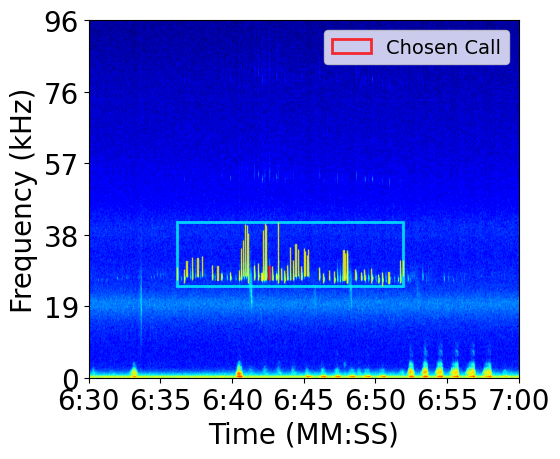

In [82]:
audio_seg = audio_features['audio_seg']
fs = audio_features['sample_rate']
start = audio_features['start']
duration = audio_features['duration']

file_dt = dt.datetime.strptime(audio_features['file_path'].name, '%Y%m%d_%H%M%S.WAV')
UBNA_tz = pytz.timezone('US/Pacific')
UTC_tz = pytz.timezone('UTC')

file_dt_UTC = UTC_tz.localize(file_dt)
file_dt_PST = file_dt_UTC.astimezone(UBNA_tz)
file_title = f'{file_dt_PST.date()} {file_dt_PST.time()} PST'

plt.figure(figsize=audio_features['figsize'])
plt.rcParams.update({'font.size': 20})
# plt.title(f"BCI-derived bouts using BD2 detections on {audio_features['file_path'].name}", fontsize=22)
plt.specgram(audio_seg, NFFT=spec_features['NFFT'], cmap=spec_features['cmap'], vmin=spec_features['vmin'])

legend_patches = []
for group in bout_params.keys():
    type_tag = group.split('_')[0]
    
    if group != 'site_key' and (type_tag in plot_bouts['freq_group'].values):
        group_tag = group.split('_')[0]
        group_patch = patches.Patch(facecolor=FREQUENCY_COLOR_MAPPINGS[group_tag], edgecolor='k', label=f'{type_tag.upper()} Bouts')
        legend_patches += [group_patch]

ax = plt.gca()
plot_bout_info(ax, audio_features, selected_bout)
    
if len(plot_dets)>0:
    for i, row in plot_dets.iterrows():
        if row['freq_group'] == selected_bout.iloc[0]['freq_group']:
            if row['start_time']==chosen_call['start_time']:
                rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                                (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                                linewidth=2, edgecolor='red', facecolor='none', alpha=0.8, label='Chosen Call')
            else:
                rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                            (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                            linewidth=1, edgecolor='yellow', facecolor='none', alpha=0.8)
        
            ax.add_patch(rect)

windows_PST = pd.date_range(file_dt_PST+pd.Timedelta(seconds=start), file_dt_PST+pd.Timedelta(seconds=start)+pd.Timedelta(seconds=duration), freq=f'{duration//6}S', inclusive='both')

plt.yticks(ticks=np.linspace(0, 1*(96/125), 6), labels=np.linspace(0, 192000/2000, 6).astype('int'))
plt.xticks(ticks=np.linspace(0, duration*(fs/2), len(windows_PST)), labels=windows_PST.strftime('%-M:%S'), color='k')
plt.ylabel("Frequency (kHz)")
plt.xlabel("Time (MM:SS)")
plt.ylim(0, 96/125)
plt.legend(fontsize=14, loc='upper right')

plt.tight_layout()
plt.show()

In [165]:
def pad_call_ms(call, fs, window_dur):
    window_samples = int(fs*window_dur)
    call_samples = len(call)
    padded_call = np.pad(call, np.ceil((window_samples - call_samples)/2).astype(int), mode='constant', constant_values=1e-4)

    return padded_call

In [27]:
bout_dets = plot_dets.loc[(plot_dets['start_time']>=selected_bout.iloc[0]['start_time'])&(plot_dets['end_time']<=selected_bout.iloc[0]['end_time'])]
bout_dets.reset_index(drop=True, inplace=True)
bout_dets.shape

(56, 22)

In [83]:
chosen_call

index                                                              9249
start_time_wrt_ref                                             402.5685
end_time_wrt_ref                                               402.5847
index_in_file                                                    243652
freq_group                                                          LF1
index_in_file.1                                                     891
ref_time                                            2022-07-28 08:00:00
call_start_time                              2022-07-28 08:06:42.568500
call_end_time                                2022-07-28 08:06:42.584700
start_time                                                     402.5685
end_time                                                       402.5847
low_freq                                                        26328.0
high_freq                                                       30144.0
event                                                      Echol

In [153]:
def get_snr_from_band_limited_signal(snr_call_signal, snr_noise_signal): 

    signal_power_rms = np.sqrt(np.square(snr_call_signal).mean())
    noise_power_rms = np.sqrt(np.square(snr_noise_signal).mean())
    snr = abs(20 * np.log10(signal_power_rms / noise_power_rms))

    return snr


def bandpass_audio_signal(audio_seg, fs, low_freq_cutoff, high_freq_cutoff):
    nyq = fs // 2
    low_cutoff = (low_freq_cutoff) / nyq
    high_cutoff =  (high_freq_cutoff) / nyq
    b, a = scipy.signal.butter(4, [low_cutoff, high_cutoff], btype='band', analog=False)
    band_limited_audio_seg = scipy.signal.filtfilt(b, a, audio_seg)

    return band_limited_audio_seg

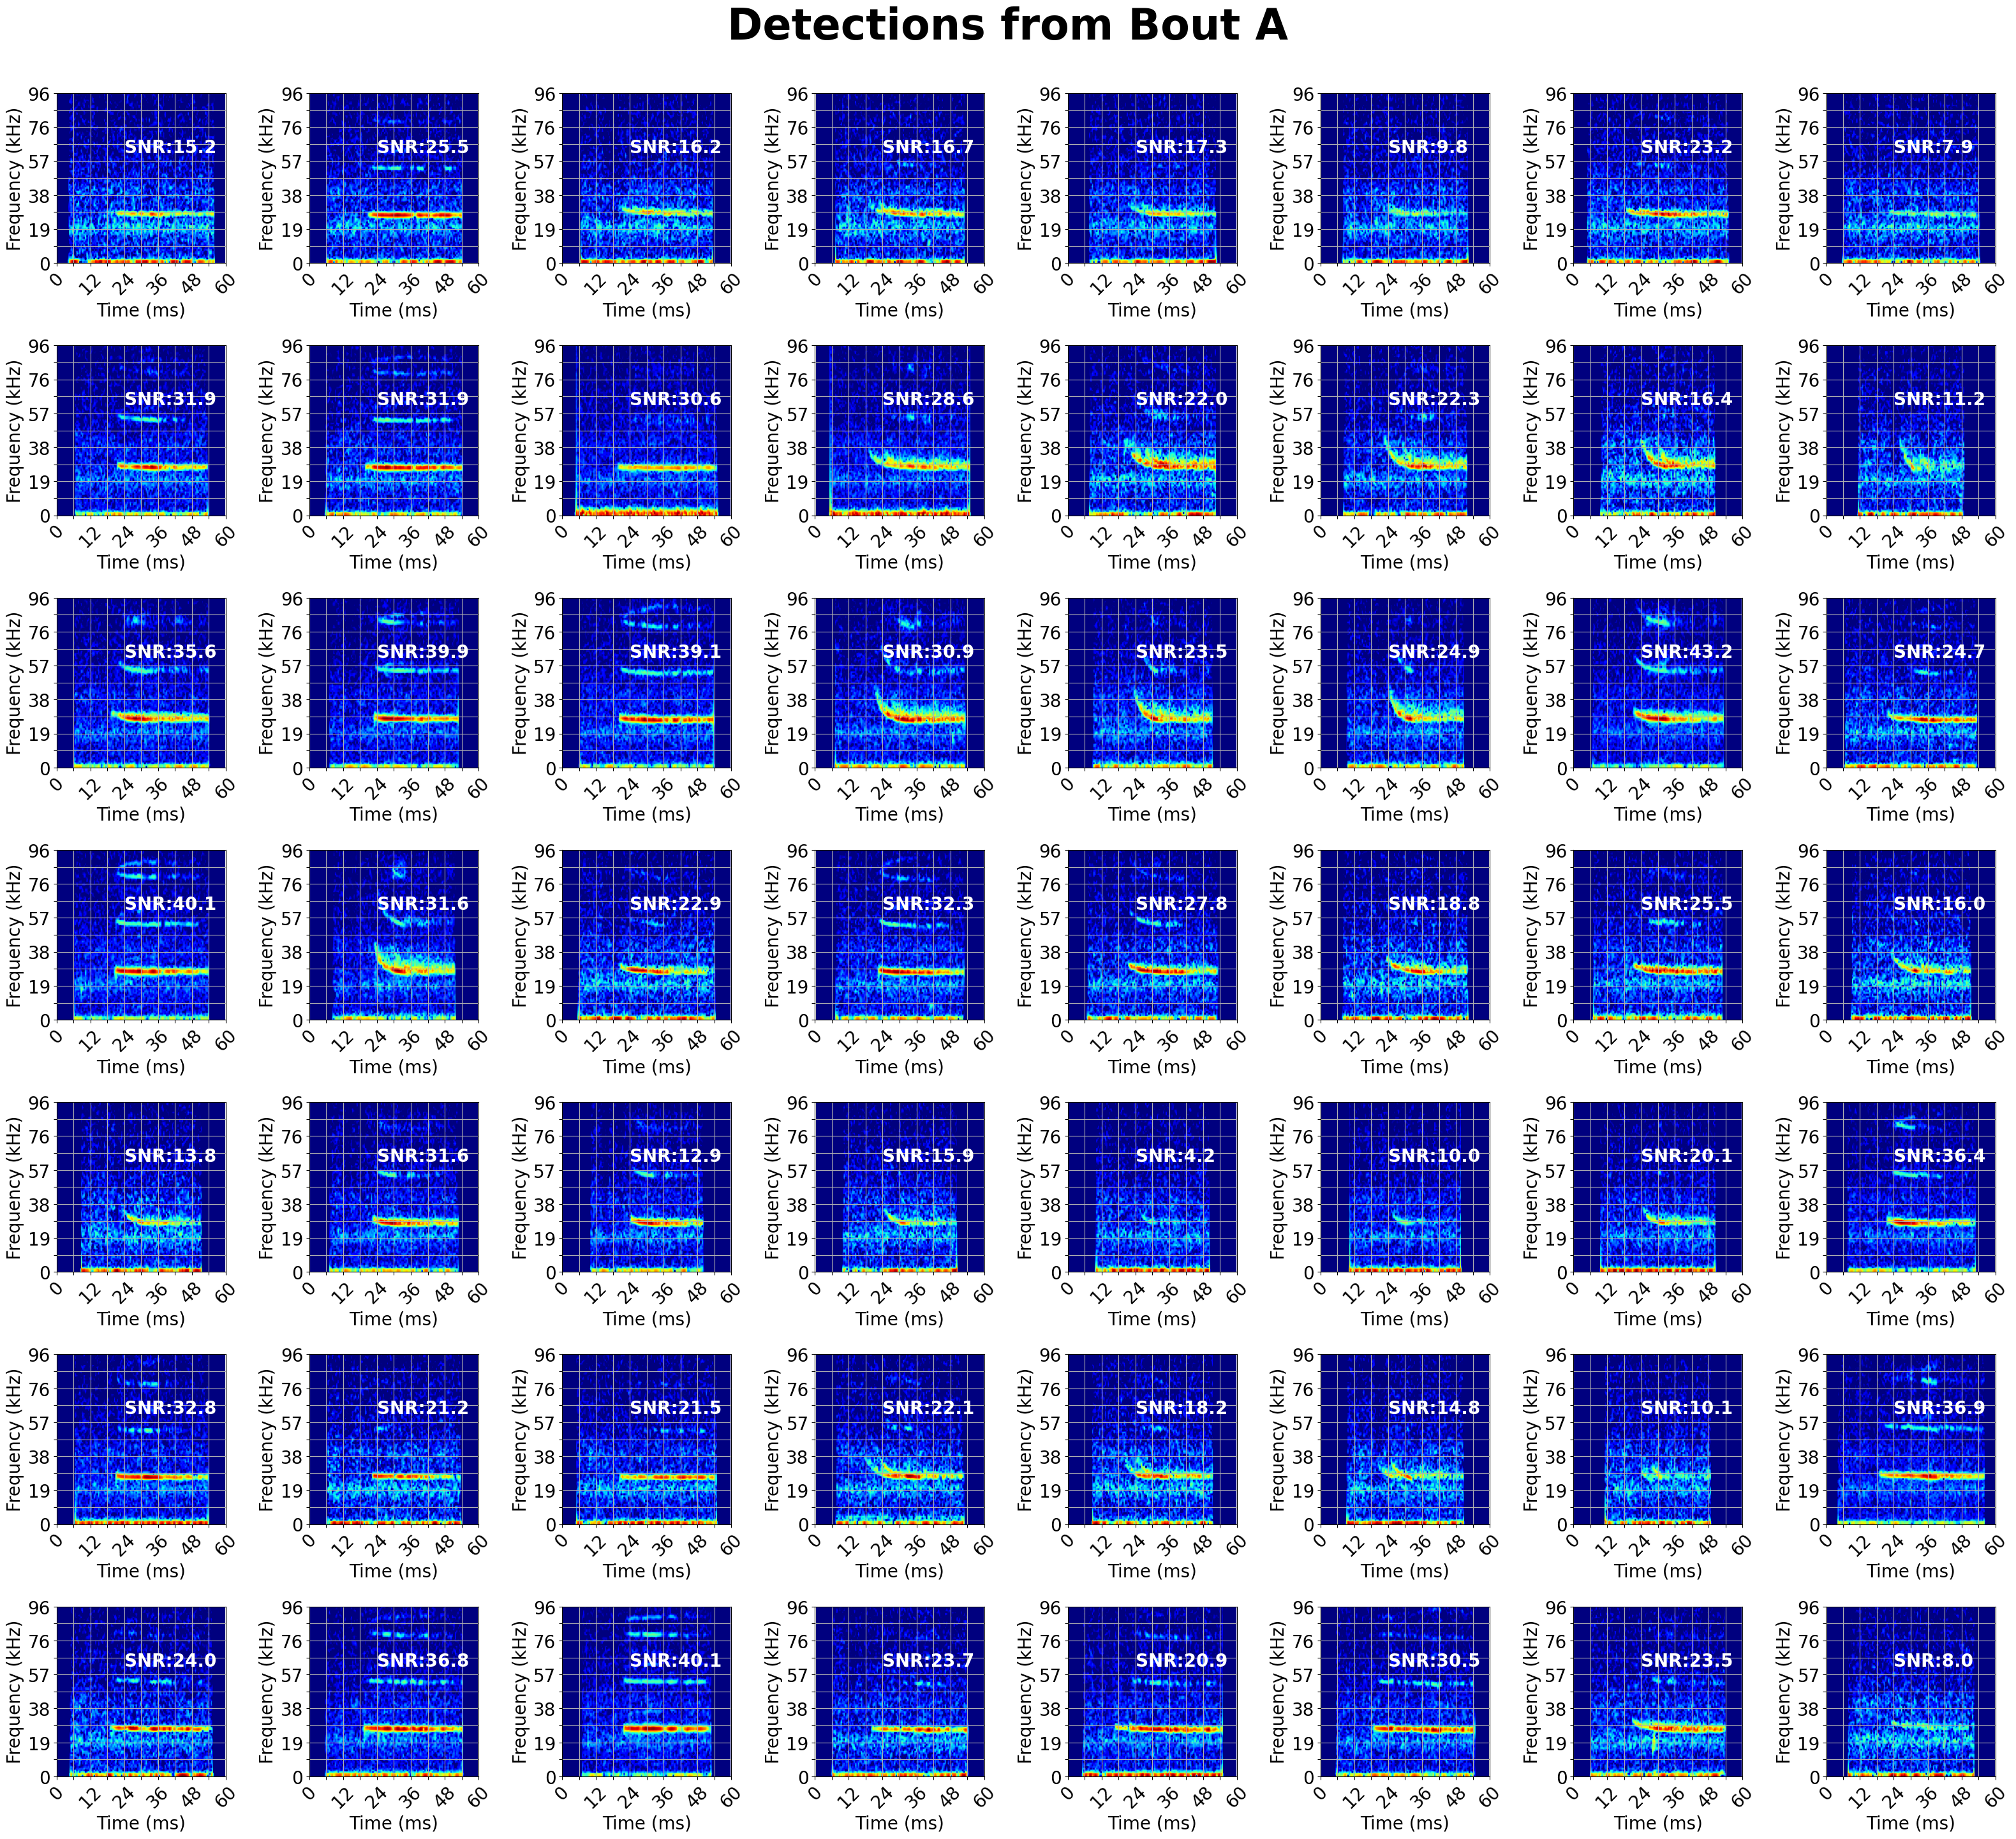

In [166]:
plt.figure(figsize=(4*len(bout_dets)/7,4*8))
plt.suptitle('Detections from Bout A', fontsize=48, weight='bold', y=1.0)
for i, row in bout_dets.iterrows():
    plt.subplot(8,len(bout_dets)//7,i+1)
    call_dur = (row['end_time'] - row['start_time'])
    pad = 0.002
    start = row['start_time'] - call_dur - (3*pad)
    duration = (2 * call_dur) + (4*pad)
    end = row['end_time']
    nyquist = fs/2
    if start >=0 and end <= 1795:
        audio_file.seek(int(fs*start))
        audio_seg = audio_file.read(int(fs*duration))
        
        low_freq_cutoff = row['low_freq']-2000
        high_freq_cutoff = min(nyquist-1, row['high_freq']+2000)
        band_limited_audio_seg = bandpass_audio_signal(audio_seg, fs, low_freq_cutoff, high_freq_cutoff)

        sec_length = int(fs*(pad+call_dur+pad))
        signal = band_limited_audio_seg.copy()
        signal[:sec_length] = 0

        noise = band_limited_audio_seg - signal
        snr_call_signal = signal[-sec_length:]
        snr_noise_signal = noise[:sec_length]
        snr = get_snr_from_band_limited_signal(snr_call_signal, snr_noise_signal)

        pad = 0.015
        audio_file.seek(int(fs*(row['start_time']-pad)))
        call_for_display = audio_file.read(int(fs*((row['end_time']-row['start_time'])+(2*pad))))
        padded_call = pad_call_ms(call_for_display, fs, 0.06)

        padded_call_dur = round(len(padded_call)/fs, 2)
        plt.specgram(padded_call, NFFT=256, cmap='jet', vmin=-55)
        time_labels = (np.linspace(0,1000*padded_call_dur, 11).astype('int')).astype('str')
        time_labels[1::2] = ''
        plt.xticks(ticks=np.linspace(0,round(len(padded_call)/2), 11), labels=time_labels, rotation=45)
        ax = plt.gca()
        plt.text(x=0.4, y=0.65, s=f'SNR:{round(snr, 1)}', color='white', fontsize=20, fontweight='bold', transform=ax.transAxes)

        low_end = 0
        high_end = 96000
        freq_labels = (np.linspace(low_end/1000, high_end/1000, 11)).astype('int').astype('str')
        freq_labels[1::2] = ''
        plt.yticks(ticks=np.linspace(2*low_end/(fs), 2*high_end/(fs), 11), labels=freq_labels)
        plt.ylim(2*low_end/(fs), 2*high_end/(fs))
        plt.xlabel('Time (ms)')
        plt.ylabel('Frequency (kHz)')
        plt.grid(which='both')

plt.tight_layout()
plt.show()